In [1]:
import numpy as np
import base
import matrix
import matplotlib.pyplot as plt


In [2]:
A = matrix.load_matrix('testmatrix_rand(0_2)_N32_t_0_anim.txt').reshape(32,32) # matrix I used for animation
points = np.arange(len(A))

## Autocorrelation

# to do Autocorrelation
# to do Uncertainty

In [3]:
dist,mc_hist,temp = base.traveling_MC_constDist_history(points,A,20000)

C:\Users\Win10\Computational physics\Projects\base.py:155: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


In [4]:
def autocorrelation(timeseries, mean=None):
    if mean is None:
        mean = timeseries.mean()
    fluctuations = timeseries-mean

    C = np.fft.ifft(np.fft.fft(fluctuations) * np.fft.ifft(fluctuations)).real
    return C/C[0]

def integrated_autocorrelation_time(timeseries, mean=None, until=None):
    steps = len(timeseries)
    if until is None:
        until = steps // 2
    Gamma = autocorrelation(timeseries, mean=mean)[:until]
    try:
        first_zero = np.where(Gamma <= 0)[0][0]
        return int(np.ceil(0.5 + Gamma[1:first_zero].sum()))
    except:
        # Gamma never hits 0.  So the autocorrelation spans ~ the whole ensemble.
        return steps # at least!

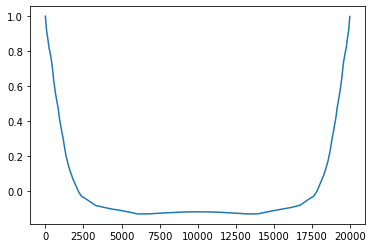

In [5]:
plt.plot(autocorrelation(dist))

In [6]:
print(integrated_autocorrelation_time(dist))

843


# Different Temperatures and alphas

In [8]:
T = [1000.0, 100.0, 10.0, 1.0, 0.1, 0.01, 0.001]
alpha = [1,0.99 , 0.95 ,0.9,0.85,0.8,0.5,0.1]


In [9]:
def what(a,b):
    c = a
    l = b
    k = f'Temp ={a},alpha = {b}'
    return c,l,k

In [10]:
store = []
wha = []
for temp in T:
    for a in alpha:
        store.append(base.traveling_MC_constDist(points,A,20000,starting_temp=temp,alpha=a)[1])
        #wha.append(what(temp,a))

C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: overflow encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: divide by zero encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: invalid value encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


In [13]:

T_1000 = np.array(store[0:8])
T_100 = np.array(store[8:16])
T_10 = np.array(store[16:24])
T_1 = np.array(store[24:32])
T_0_1 = np.array(store[32:40])
T_0_01 = np.array(store[40:48])
T_0_001 = np.array(store[48:])

In [14]:
print(T_1000[:,-1])

[32.44  9.78  9.66  9.65 10.27  9.92  9.9  10.19]


In [15]:
result = np.array([T_1000[:,-1],T_100[:,-1],T_10[:,-1],T_1[:,-1],T_0_1[:,-1],T_0_01[:,-1],T_0_001[:,-1]])
print(result)

[[32.44  9.78  9.66  9.65 10.27  9.92  9.9  10.19]
 [30.18  9.66  9.65 10.39 10.14  9.65  9.65  9.65]
 [27.19  9.82  9.65 10.07 10.17  9.65  9.93  9.65]
 [23.25 10.45 10.51 10.11  9.78 10.11  9.65  9.78]
 [10.66  9.83  9.93  9.66 10.67  9.65  9.65  9.66]
 [ 9.97  9.65  9.65 10.54  9.96  9.66  9.66 10.  ]
 [ 9.65 10.54  9.93  9.65  9.65 10.14 10.18 10.25]]


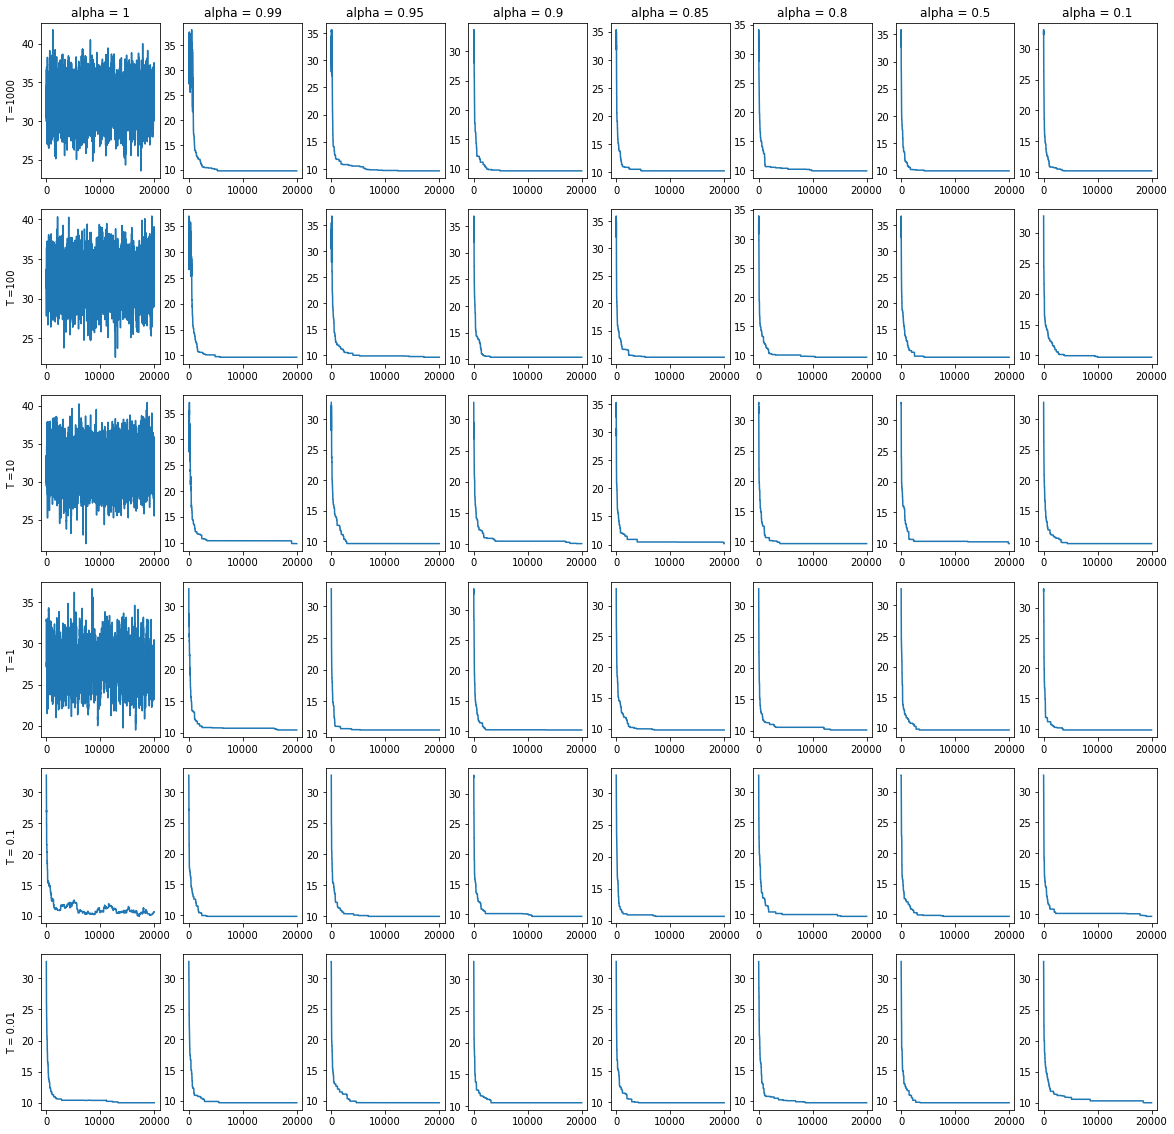

In [16]:
fig, (ax1000,ax100,ax10,ax1,ax_1,ax_01) = plt.subplots(6,8,figsize=(20,20))
for x in range(len(T_1000)):
    ax1000[x].plot(T_1000[x])
    ax100[x].plot(T_100[x])
    ax10[x].plot(T_10[x])
    ax1[x].plot(T_1[x])
    ax_1[x].plot(T_0_1[x])
    ax_01[x].plot(T_0_01[x])
    ax1000[x].set_title(f'alpha = {alpha[x]}')
ax1000[0].set_ylabel('T =1000')
ax100[0].set_ylabel('T =100')
ax10[0].set_ylabel('T =10')
ax1[0].set_ylabel('T =1')
ax_1[0].set_ylabel('T = 0.1')
ax_01[0].set_ylabel('T = 0.01')
plt.show()

As long as $\alpha < 1$ we get a samll distance as result.

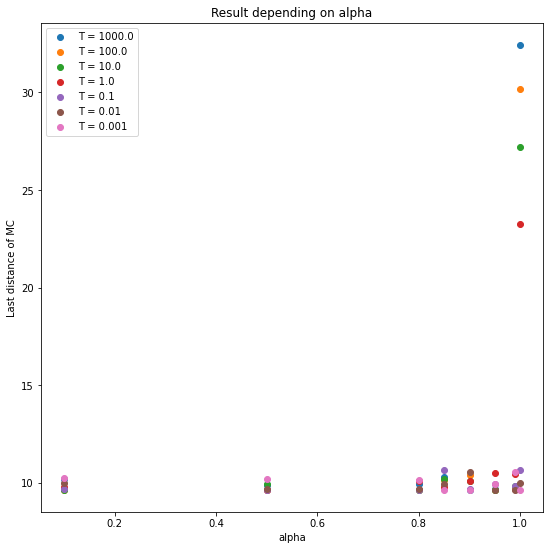

In [17]:
fig, ax = plt.subplots(figsize=(9,9))
for x in range(len(T)):
    ax.scatter(alpha,result[x],label =f'T = {T[x]}')
    ax.legend()
    ax.set_ylabel('Last distance of MC')
    ax.set_xlabel('alpha')
    ax.set_title('Result depending on alpha')

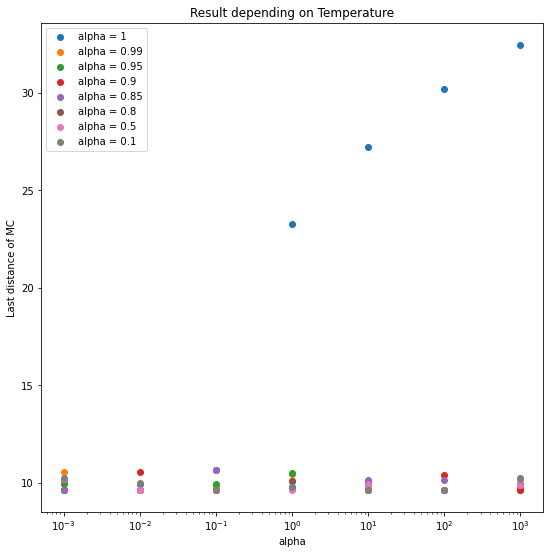

In [18]:
fig, ax = plt.subplots(figsize=(9,9))
for x in range(len(alpha)):
    ax.scatter(T,result.T[x],label =f'alpha = {alpha[x]}')
    ax.legend()
    ax.set_ylabel('Last distance of MC')
    ax.set_xlabel('alpha')
    ax.set_title('Result depending on Temperature')
    ax.set_xscale('log')

# Different Temperatures and alphas with Christofides start -> start in local minimum

In [21]:
import tsp
points2=tsp.christofides_all(A)[:-1]
print(points2)

[16 28 14 13  8 27 30 22 23 21 25 31 18 29 12 24  4 26 17  9 19 15  7 20
  1  3 11  5  2  0  6 10]


In [28]:
print(base.totalTravelDist(points2,A))

10.829999999999998


In [23]:
store = []
wha = []
for temp in T:
    for a in alpha:
        store.append(base.traveling_MC_constDist(points2,A,20000,starting_temp=temp,alpha=a)[1])
T_1000 = np.array(store[0:8])
T_100 = np.array(store[8:16])
T_10 = np.array(store[16:24])
T_1 = np.array(store[24:32])
T_0_1 = np.array(store[32:40])
T_0_01 = np.array(store[40:48])
T_0_001 = np.array(store[48:])
result = np.array([T_1000[:,-1],T_100[:,-1],T_10[:,-1],T_1[:,-1],T_0_1[:,-1],T_0_01[:,-1],T_0_001[:,-1]])

C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: overflow encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: divide by zero encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: invalid value encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


In [26]:
print(result)

[[28.02  9.98 10.09 10.3  10.06  9.98 10.46 10.16]
 [30.42  9.9  10.07  9.88  9.95 10.09 10.28  9.66]
 [33.66 10.36  9.83 10.12 10.51 10.26  9.95 10.  ]
 [22.53 10.35 10.29 10.29 10.27 10.   10.17 10.17]
 [11.11 10.26  9.88  9.88  9.88  9.88  9.88  9.88]
 [10.17 10.29 10.17 10.   10.17 10.   10.   10.  ]
 [10.31 10.17  9.78  9.88  9.88 10.3   9.88 10.  ]]


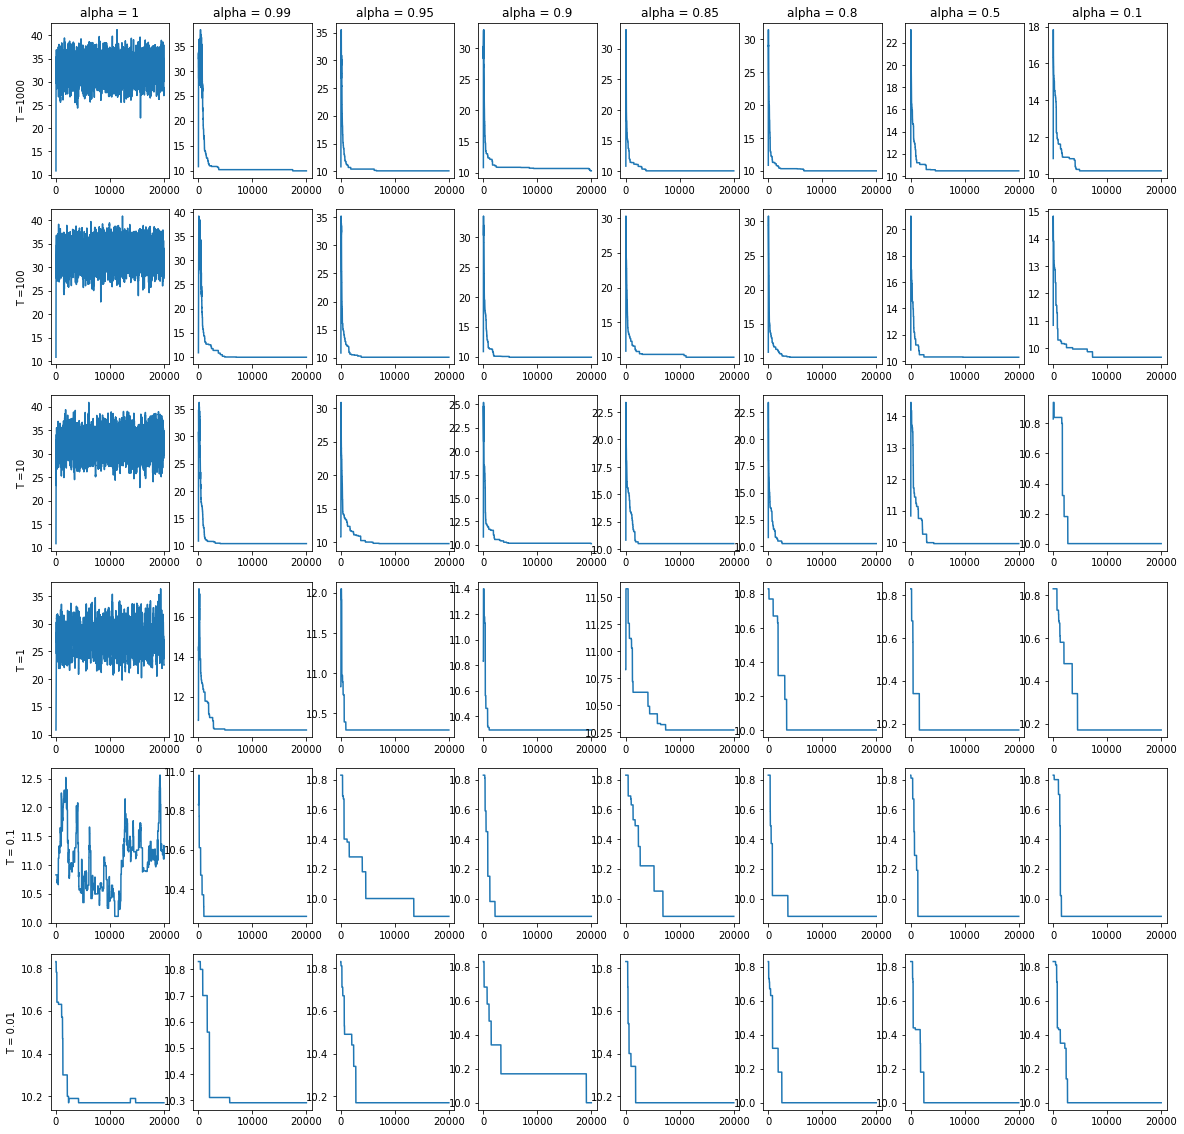

In [24]:
fig, (ax1000,ax100,ax10,ax1,ax_1,ax_01) = plt.subplots(6,8,figsize=(20,20))
for x in range(len(T_1000)):
    ax1000[x].plot(T_1000[x])
    ax100[x].plot(T_100[x])
    ax10[x].plot(T_10[x])
    ax1[x].plot(T_1[x])
    ax_1[x].plot(T_0_1[x])
    ax_01[x].plot(T_0_01[x])
    ax1000[x].set_title(f'alpha = {alpha[x]}')
ax1000[0].set_ylabel('T =1000')
ax100[0].set_ylabel('T =100')
ax10[0].set_ylabel('T =10')
ax1[0].set_ylabel('T =1')
ax_1[0].set_ylabel('T = 0.1')
ax_01[0].set_ylabel('T = 0.01')
plt.show()

We see for high alphas<1 and high T we have more time to exit local Minimum

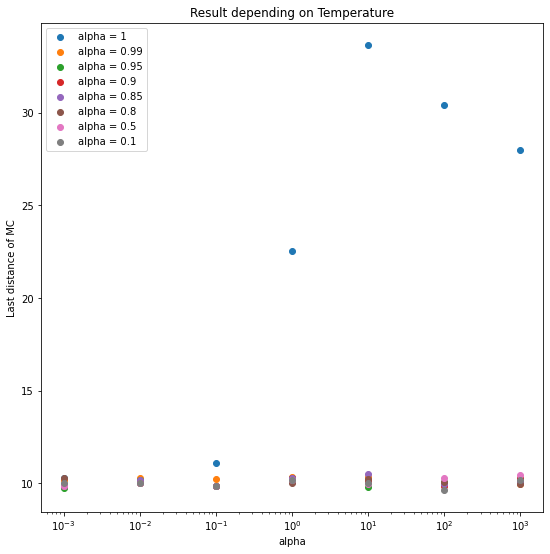

In [25]:
fig, ax = plt.subplots(figsize=(9,9))
for x in range(len(alpha)):
    ax.scatter(T,result.T[x],label =f'alpha = {alpha[x]}')
    ax.legend()
    ax.set_ylabel('Last distance of MC')
    ax.set_xlabel('alpha')
    ax.set_title('Result depending on Temperature')
    ax.set_xscale('log')

# same idea  less steps

C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: overflow encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: divide by zero encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: invalid value encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


[[35.1   9.95 11.77 10.9  10.97 10.65 10.47 10.8 ]
 [32.33 11.54 11.03 10.89 10.6  11.02 10.55 10.36]
 [32.41 11.23 11.13 10.66 10.42 11.24 10.07 10.71]
 [25.68 11.13 10.07 10.12 10.59 10.43 10.22 10.34]
 [11.31 10.18 10.23 10.56 10.22 10.37 10.56  9.88]
 [10.61 10.35  9.98  9.88  9.88 10.   10.23 10.56]
 [10.37 10.33 10.53 10.   10.32 10.34 10.56  9.88]]


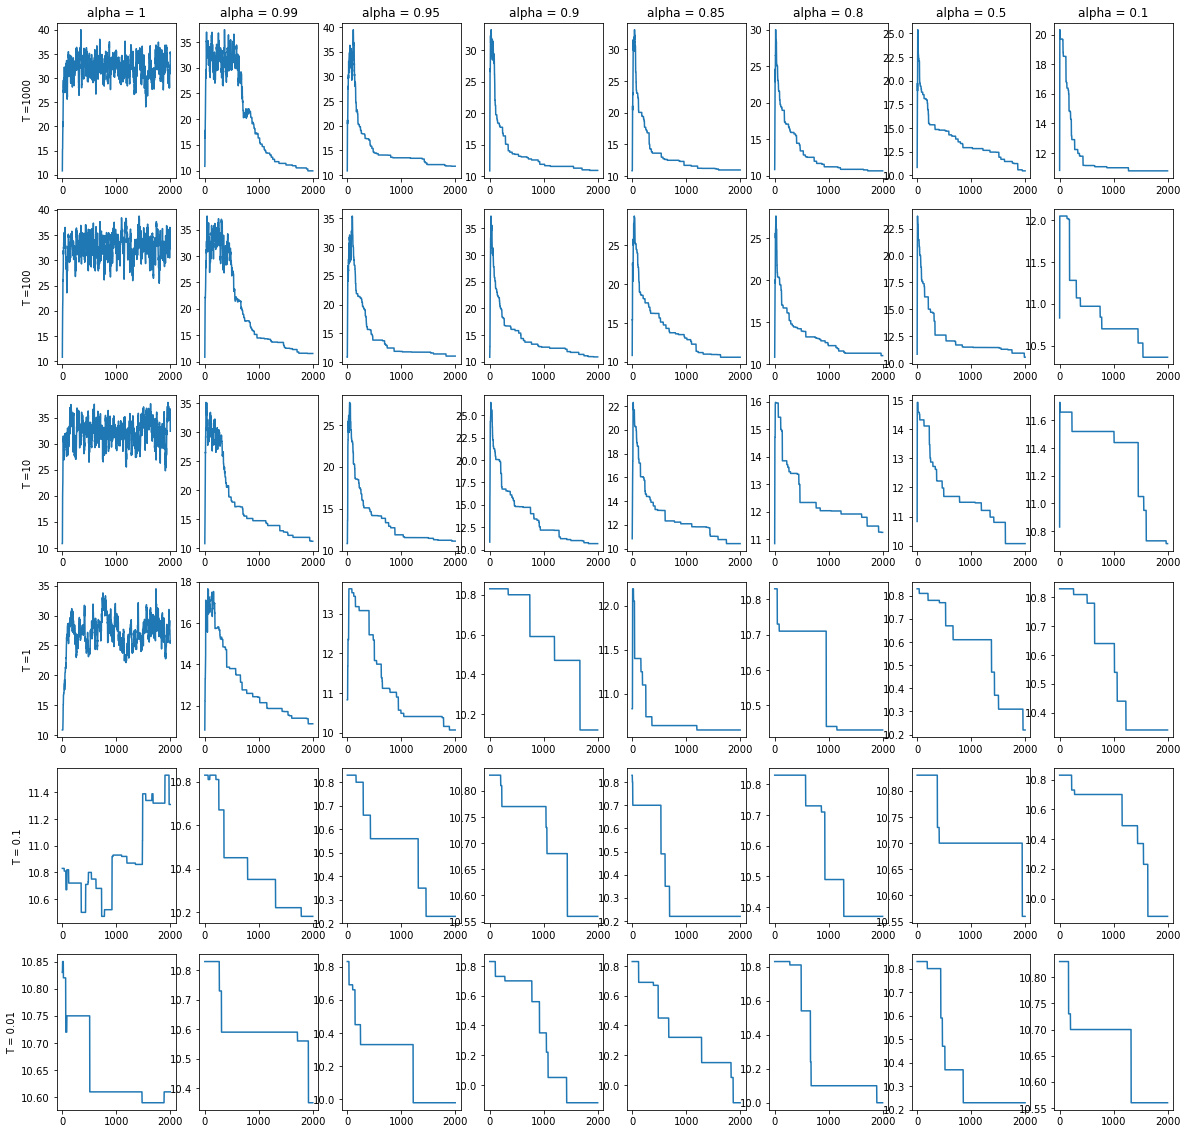

In [29]:
store = []
wha = []
for temp in T:
    for a in alpha:
        store.append(base.traveling_MC_constDist(points2,A,2000,starting_temp=temp,alpha=a)[1])
T_1000 = np.array(store[0:8])
T_100 = np.array(store[8:16])
T_10 = np.array(store[16:24])
T_1 = np.array(store[24:32])
T_0_1 = np.array(store[32:40])
T_0_01 = np.array(store[40:48])
T_0_001 = np.array(store[48:])
result = np.array([T_1000[:,-1],T_100[:,-1],T_10[:,-1],T_1[:,-1],T_0_1[:,-1],T_0_01[:,-1],T_0_001[:,-1]])
print(result)
fig, (ax1000,ax100,ax10,ax1,ax_1,ax_01) = plt.subplots(6,8,figsize=(20,20))
for x in range(len(T_1000)):
    ax1000[x].plot(T_1000[x])
    ax100[x].plot(T_100[x])
    ax10[x].plot(T_10[x])
    ax1[x].plot(T_1[x])
    ax_1[x].plot(T_0_1[x])
    ax_01[x].plot(T_0_01[x])
    ax1000[x].set_title(f'alpha = {alpha[x]}')
ax1000[0].set_ylabel('T =1000')
ax100[0].set_ylabel('T =100')
ax10[0].set_ylabel('T =10')
ax1[0].set_ylabel('T =1')
ax_1[0].set_ylabel('T = 0.1')
ax_01[0].set_ylabel('T = 0.01')
plt.show()